# 1. Import Required Libraries

In [ ]:

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, List, Dict, Any
import logging
from pathlib import Path
import warnings


In [ ]:
# Configure matplotlib for better plots
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

GPU available: []


In [ ]:

# Configuration parameters
CONFIG = {
    'IMAGE_URL': 'https://www.nhm.ac.uk/content/dam/nhm-www/discover/sea-snakes-kraits/sea-snake-banded-krait-full-width.jpg',
    'MODEL_NAME': 'VGG16',
    'INPUT_SHAPE': (224, 224),
    'EPSILON_VALUES': [0.1, 10, 50],
    'SIGMA_VALUES': [0.1, 10, 100],
    'NUM_CLASSES': 1000
}

for key, value in CONFIG.items():
    print(f"   {key}: {value}")

   IMAGE_URL: https://www.nhm.ac.uk/content/dam/nhm-www/discover/sea-snakes-kraits/sea-snake-banded-krait-full-width.jpg
   MODEL_NAME: VGG16
   INPUT_SHAPE: (224, 224)
   EPSILON_VALUES: [0.1, 10, 50]
   SIGMA_VALUES: [0.1, 10, 100]
   NUM_CLASSES: 1000


In [ ]:
class AdversarialAttackGenerator:
    """
    A comprehensive class for generating and analyzing adversarial attacks
    using Fast Gradient Sign Method (FGSM) and Gaussian noise.
    """

    def __init__(self, model_name: str = 'VGG16', input_shape: Tuple[int, int] = (224, 224)):
        """
        Initialize the adversarial attack generator.

        Args:
            model_name: Name of the pre-trained model to use
            input_shape: Input image dimensions (height, width)
        """
        self.model_name = model_name
        self.input_shape = input_shape
        self.model = self._load_pretrained_model()
        self.loss_fn = tf.keras.losses.CategoricalCrossentropy()

        logger.info(f"Initialized {model_name} adversarial attack generator")

    def _load_pretrained_model(self) -> tf.keras.Model:
        """Load and configure the pre-trained model."""
        try:
            if self.model_name == 'VGG16':
                model = tf.keras.applications.VGG16(
                    include_top=True,
                    weights='imagenet'
                )
            else:
                raise ValueError(f"Model {self.model_name} not supported")

            model.trainable = False
            logger.info(f"Successfully loaded {self.model_name} model")
            return model

        except Exception as e:
            logger.error(f"Failed to load model: {e}")
            raise

    def preprocess_image(self, image: tf.Tensor) -> tf.Tensor:
        """
        Preprocess image for model input.

        Args:
            image: Raw image tensor

        Returns:
            Preprocessed image tensor
        """
        image = tf.cast(image, tf.float32)
        image = tf.image.resize(image, self.input_shape)

        if self.model_name == 'VGG16':
            image = tf.keras.applications.vgg16.preprocess_input(image)

        image = tf.expand_dims(image, axis=0)
        return image

    def deprocess_image(self, image: tf.Tensor) -> np.ndarray:
        """
        Convert preprocessed image back to displayable format.

        Args:
            image: Preprocessed image tensor

        Returns:
            Displayable image array
        """
        # Reverse BGR to RGB for VGG16
        image = image[..., ::-1]
        image = tf.clip_by_value(image / 255.0, 0.0, 1.0)
        return image.numpy()

    def load_and_preprocess_image(self, image_url: str) -> Tuple[tf.Tensor, np.ndarray]:
        """
        Load and preprocess image from URL.

        Args:
            image_url: URL of the image to load

        Returns:
            Tuple of (preprocessed_image, original_image)
        """
        try:
            # Download image
            image_path = tf.keras.utils.get_file(
                'target_image.jpg',
                image_url,
                cache_dir='./images'
            )

            # Read and decode image
            image_raw = tf.io.read_file(image_path)
            image = tf.image.decode_image(image_raw, channels=3)

            # Store original for display
            original_img = tf.image.convert_image_dtype(image, tf.float32).numpy()

            # Preprocess for model
            preprocessed_img = self.preprocess_image(image)

            logger.info(f"Image loaded successfully: {original_img.shape} -> {preprocessed_img.shape}")

            return preprocessed_img, original_img

        except Exception as e:
            logger.error(f"Failed to load image: {e}")
            raise

    def predict_image(self, image: tf.Tensor) -> Tuple[np.ndarray, str, float, int]:
        """
        Get model prediction for an image.

        Args:
            image: Preprocessed image tensor

        Returns:
            Tuple of (probabilities, predicted_class, confidence, class_index)
        """
        try:
            predictions = self.model.predict(image, verbose=0)
            predicted_class_idx = np.argmax(predictions)
            confidence = np.max(predictions)

            # Decode class name
            decoded_predictions = tf.keras.applications.imagenet_utils.decode_predictions(
                predictions, top=1
            )
            predicted_class = decoded_predictions[0][0][1]

            return predictions, predicted_class, confidence, predicted_class_idx

        except Exception as e:
            logger.error(f"Prediction failed: {e}")
            raise

    def create_adversarial_pattern(self, image: tf.Tensor, target_class: int) -> tf.Tensor:
        """
        Generate adversarial perturbation using FGSM.

        Args:
            image: Input image tensor
            target_class: Target class index for the attack

        Returns:
            Adversarial perturbation tensor
        """
        # Create one-hot encoded target
        target_label = tf.one_hot([target_class], depth=1000)

        with tf.GradientTape() as tape:
            tape.watch(image)
            predictions = self.model(image)
            loss = self.loss_fn(target_label, predictions)

        # Calculate gradients and create signed perturbation
        gradients = tape.gradient(loss, image)
        signed_grad = tf.sign(gradients)

        return signed_grad

    def generate_fgsm_attack(self,
                           image: tf.Tensor,
                           target_class: int,
                           epsilon_values: List[float]) -> List[Dict[str, Any]]:
        """
        Generate FGSM adversarial examples with different epsilon values.

        Args:
            image: Original image tensor
            target_class: Target class index
            epsilon_values: List of epsilon values to test

        Returns:
            List of attack results
        """
        perturbation = self.create_adversarial_pattern(image, target_class)
        results = []

        for eps in epsilon_values:
            # Generate adversarial example
            adversarial_image = image + eps * perturbation
            adversarial_image = tf.clip_by_value(adversarial_image, 0.0, 255.0)

            # Get prediction
            probs, pred_class, confidence, _ = self.predict_image(adversarial_image)

            results.append({
                'epsilon': eps,
                'image': adversarial_image,
                'prediction': pred_class,
                'confidence': confidence,
                'probabilities': probs,
                'perturbation': perturbation
            })

            logger.info(f"FGSM ε={eps}: {pred_class} (confidence: {confidence:.4f})")

        return results

    def generate_gaussian_noise_attack(self,
                                     image: tf.Tensor,
                                     sigma_values: List[float]) -> List[Dict[str, Any]]:
        """
        Generate Gaussian noise attacks with different sigma values.

        Args:
            image: Original image tensor
            sigma_values: List of standard deviation values

        Returns:
            List of attack results
        """
        results = []

        for sigma in sigma_values:
            # Generate Gaussian noise
            noise = tf.random.normal(shape=image.shape, mean=0.0, stddev=sigma)
            noisy_image = image + noise
            noisy_image = tf.clip_by_value(noisy_image, 0.0, 255.0)

            # Get prediction
            probs, pred_class, confidence, _ = self.predict_image(noisy_image)

            results.append({
                'sigma': sigma,
                'image': noisy_image,
                'prediction': pred_class,
                'confidence': confidence,
                'probabilities': probs,
                'noise': noise
            })

            logger.info(f"Gaussian σ={sigma}: {pred_class} (confidence: {confidence:.4f})")

        return results

In [ ]:
class AttackVisualizer:
    """Class for visualizing adversarial attack results."""

    def __init__(self, attack_generator: AdversarialAttackGenerator):
        """Initialize visualizer with attack generator."""
        self.attack_gen = attack_generator

    def plot_image_comparison(self,
                            original_image: tf.Tensor,
                            original_pred: str,
                            original_conf: float) -> None:
        """Plot original image with prediction."""
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))

        ax.imshow(self.attack_gen.deprocess_image(original_image[0]))
        ax.set_title(f'Original Image\n{original_pred}\nConfidence: {original_conf:.4f}',
                    fontsize=14, fontweight='bold')
        ax.axis('off')

        plt.tight_layout()
        plt.show()

    def plot_fgsm_results(self,
                         original_image: tf.Tensor,
                         original_pred: str,
                         original_conf: float,
                         fgsm_results: List[Dict[str, Any]]) -> None:
        """Plot FGSM attack results."""
        fig, axes = plt.subplots(2, len(fgsm_results) + 1, figsize=(16, 8))
        fig.suptitle('FGSM Adversarial Attack Results', fontsize=16, fontweight='bold')

        # Original image (top-left)
        axes[0, 0].imshow(self.attack_gen.deprocess_image(original_image[0]))
        axes[0, 0].set_title(f'Original\n{original_pred}\nConf: {original_conf:.3f}')
        axes[0, 0].axis('off')

        # Perturbation visualization (bottom-left)
        if fgsm_results:
            perturbation = fgsm_results[0]['perturbation']
            axes[1, 0].imshow(tf.squeeze(perturbation), cmap='RdBu', vmin=-1, vmax=1)
            axes[1, 0].set_title('FGSM\nPerturbation')
            axes[1, 0].axis('off')

        # FGSM results
        for i, result in enumerate(fgsm_results):
            # Adversarial image
            axes[0, i+1].imshow(self.attack_gen.deprocess_image(result['image'][0]))
            axes[0, i+1].set_title(f'ε={result["epsilon"]}\n{result["prediction"]}\nConf: {result["confidence"]:.3f}')
            axes[0, i+1].axis('off')

            # Difference from original
            diff = result['image'][0] - original_image[0]
            axes[1, i+1].imshow(tf.squeeze(diff), cmap='RdBu', vmin=-50, vmax=50)
            axes[1, i+1].set_title(f'Difference\n(ε={result["epsilon"]})')
            axes[1, i+1].axis('off')

        plt.tight_layout()
        plt.show()

    def plot_gaussian_results(self,
                            original_image: tf.Tensor,
                            original_pred: str,
                            original_conf: float,
                            gaussian_results: List[Dict[str, Any]]) -> None:
        """Plot Gaussian noise attack results."""
        fig, axes = plt.subplots(2, len(gaussian_results) + 1, figsize=(16, 8))
        fig.suptitle('Gaussian Noise Attack Results', fontsize=16, fontweight='bold')

        # Original image (top-left)
        axes[0, 0].imshow(self.attack_gen.deprocess_image(original_image[0]))
        axes[0, 0].set_title(f'Original\n{original_pred}\nConf: {original_conf:.3f}')
        axes[0, 0].axis('off')

        # Empty bottom-left
        axes[1, 0].axis('off')

        # Gaussian noise results
        for i, result in enumerate(gaussian_results):
            # Noisy image
            axes[0, i+1].imshow(self.attack_gen.deprocess_image(result['image'][0]))
            axes[0, i+1].set_title(f'σ={result["sigma"]}\n{result["prediction"]}\nConf: {result["confidence"]:.3f}')
            axes[0, i+1].axis('off')

            # Noise visualization
            noise_vis = tf.squeeze(result['noise']) / (2 * result["sigma"]) + 0.5
            noise_vis = tf.clip_by_value(noise_vis, 0, 1)
            axes[1, i+1].imshow(noise_vis, cmap='gray')
            axes[1, i+1].set_title(f'Noise\n(σ={result["sigma"]})')
            axes[1, i+1].axis('off')

        plt.tight_layout()
        plt.show()

    def plot_confidence_comparison(self,
                                 original_conf: float,
                                 fgsm_results: List[Dict[str, Any]],
                                 gaussian_results: List[Dict[str, Any]]) -> None:
        """Plot confidence comparison across different attacks."""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # FGSM confidence plot
        epsilons = [r['epsilon'] for r in fgsm_results]
        fgsm_confidences = [r['confidence'] for r in fgsm_results]

        ax1.plot([0] + epsilons, [original_conf] + fgsm_confidences, 'ro-',
                linewidth=3, markersize=10, label='FGSM Attack')
        ax1.axhline(y=original_conf, color='g', linestyle='--', alpha=0.7,
                   linewidth=2, label='Original Confidence')
        ax1.set_xlabel('Epsilon Value', fontsize=12)
        ax1.set_ylabel('Prediction Confidence', fontsize=12)
        ax1.set_title('FGSM Attack: Confidence vs Epsilon', fontsize=14, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        ax1.legend(fontsize=10)
        ax1.set_ylim(0, 1)

        # Gaussian noise confidence plot
        sigmas = [r['sigma'] for r in gaussian_results]
        gaussian_confidences = [r['confidence'] for r in gaussian_results]

        ax2.semilogx([0.01] + sigmas, [original_conf] + gaussian_confidences, 'bo-',
                    linewidth=3, markersize=10, label='Gaussian Noise')
        ax2.axhline(y=original_conf, color='g', linestyle='--', alpha=0.7,
                   linewidth=2, label='Original Confidence')
        ax2.set_xlabel('Sigma Value (log scale)', fontsize=12)
        ax2.set_ylabel('Prediction Confidence', fontsize=12)
        ax2.set_title('Gaussian Noise Attack: Confidence vs Sigma', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        ax2.legend(fontsize=10)
        ax2.set_ylim(0, 1)

        plt.tight_layout()
        plt.show()

    def plot_attack_effectiveness(self,
                                original_pred: str,
                                original_conf: float,
                                fgsm_results: List[Dict[str, Any]],
                                gaussian_results: List[Dict[str, Any]]) -> None:
        """Plot attack effectiveness summary."""
        # Prepare data
        attack_names = ['Original']
        confidences = [original_conf]
        colors = ['green']

        # Add FGSM results
        for result in fgsm_results:
            attack_names.append(f'FGSM ε={result["epsilon"]}')
            confidences.append(result['confidence'])
            colors.append('red' if result['prediction'] != original_pred else 'orange')

        # Add Gaussian results
        for result in gaussian_results:
            attack_names.append(f'Gaussian σ={result["sigma"]}')
            confidences.append(result['confidence'])
            colors.append('blue' if result['prediction'] != original_pred else 'lightblue')

        # Create plot
        fig, ax = plt.subplots(figsize=(12, 8))
        bars = ax.bar(attack_names, confidences, color=colors, alpha=0.8, edgecolor='black')

        # Customize plot
        ax.set_ylabel('Prediction Confidence', fontsize=12)
        ax.set_title('Attack Effectiveness Comparison', fontsize=16, fontweight='bold')
        ax.set_ylim(0, 1)
        plt.xticks(rotation=45, ha='right')

        # Add confidence values on bars
        for bar, conf in zip(bars, confidences):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{conf:.3f}', ha='center', va='bottom', fontweight='bold')

        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='green', label='Original'),
            Patch(facecolor='red', label='Successful Attack'),
            Patch(facecolor='orange', label='Failed FGSM'),
            Patch(facecolor='lightblue', label='Failed Gaussian')
        ]
        ax.legend(handles=legend_elements, loc='upper right')

        plt.tight_layout()
        plt.show()

In [ ]:
# Initialize the attack generator
attack_gen = AdversarialAttackGenerator(
    model_name=CONFIG['MODEL_NAME'],
    input_shape=CONFIG['INPUT_SHAPE']
)
visualizer = AttackVisualizer(attack_gen)

In [ ]:
# Load and preprocess the target image
preprocessed_img, original_img = attack_gen.load_and_preprocess_image(CONFIG['IMAGE_URL'])

print(f"   Original shape: {original_img.shape}")
print(f"   Preprocessed shape: {preprocessed_img.shape}")

   Original shape: (600, 1160, 3)
   Preprocessed shape: (1, 224, 224, 3)


🔍 Getting original prediction...
Class: sea_snake
Confidence: 0.9993
Class Index: 65


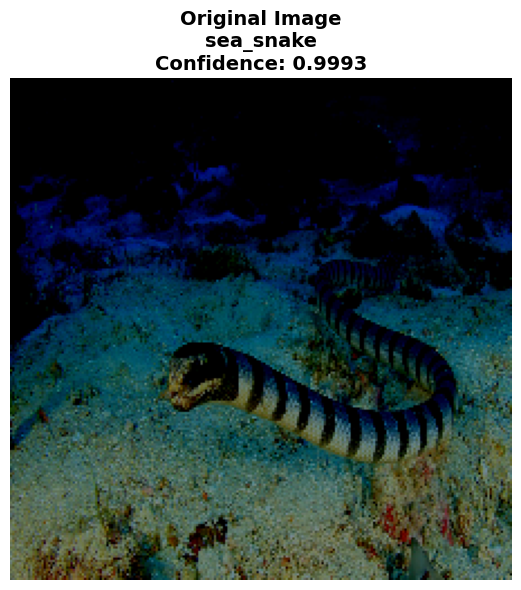

In [ ]:
# Get original prediction
print("🔍 Getting original prediction...")
original_probs, original_pred, original_conf, original_class_idx = attack_gen.predict_image(preprocessed_img)

print(f"Class: {original_pred}")
print(f"Confidence: {original_conf:.4f}")
print(f"Class Index: {original_class_idx}")

# Display original image
visualizer.plot_image_comparison(preprocessed_img, original_pred, original_conf)


FGSM attacks generated successfully!
Results summary:
   ε=   0.1: sea_snake                 (Conf: 0.937) - FAILED
   ε=    10: water_snake               (Conf: 0.684) - SUCCESS
   ε=    50: jigsaw_puzzle             (Conf: 0.662) - SUCCESS


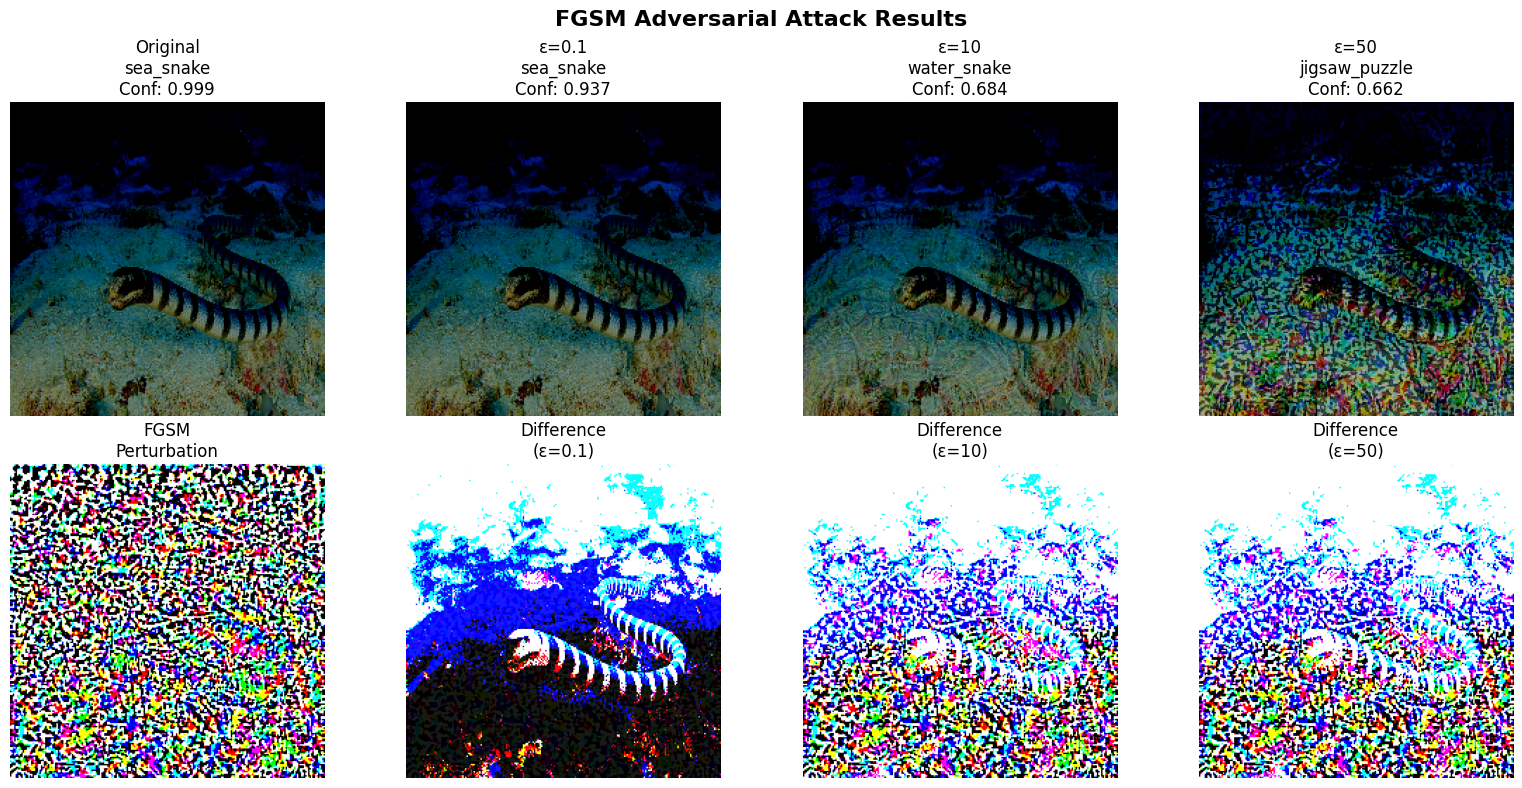

In [ ]:
# Generate FGSM attacks
fgsm_results = attack_gen.generate_fgsm_attack(
    preprocessed_img,
    original_class_idx,
    CONFIG['EPSILON_VALUES']
)

print(f"\nFGSM attacks generated successfully!")
print(f"Results summary:")
for i, result in enumerate(fgsm_results):
    success = result['prediction'] != original_pred
    status = "SUCCESS" if success else "FAILED"
    print(f"   ε={result['epsilon']:>6}: {result['prediction']:<25} "
          f"(Conf: {result['confidence']:.3f}) - {status}")

# Visualize FGSM results
visualizer.plot_fgsm_results(preprocessed_img, original_pred, original_conf, fgsm_results)



Gaussian noise attacks generated successfully!
Results summary:
   σ=   0.1: sea_snake                 (Conf: 0.948) - FAILED
   σ=    10: sea_snake                 (Conf: 0.945) - FAILED
   σ=   100: centipede                 (Conf: 0.203) - SUCCESS


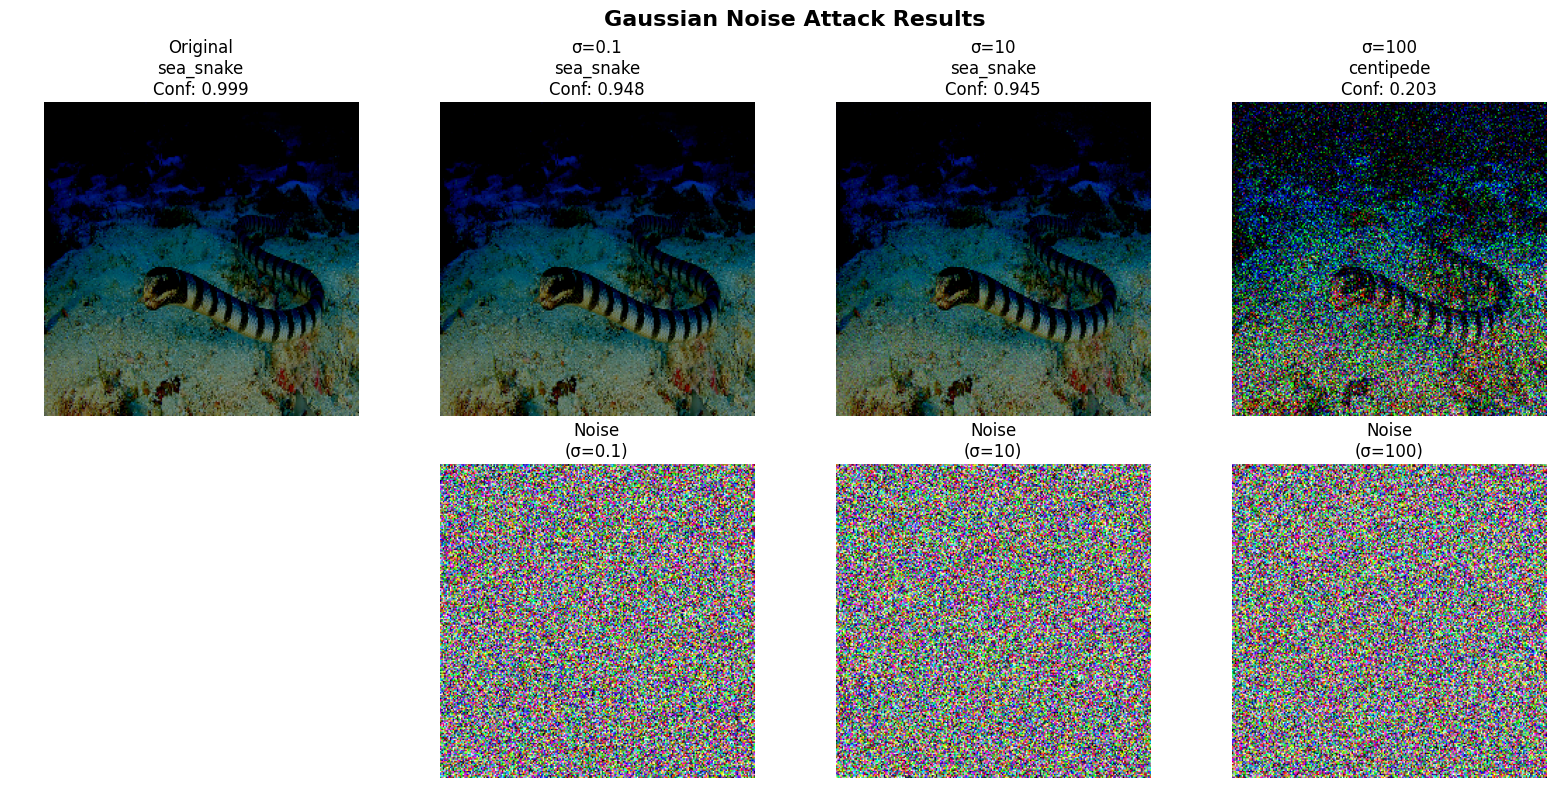

In [ ]:
# Generate Gaussian noise attacks
gaussian_results = attack_gen.generate_gaussian_noise_attack(
    preprocessed_img,
    CONFIG['SIGMA_VALUES']
)

print(f"\nGaussian noise attacks generated successfully!")
print(f"Results summary:")
for i, result in enumerate(gaussian_results):
    success = result['prediction'] != original_pred
    status = "SUCCESS" if success else "FAILED"
    print(f"   σ={result['sigma']:>6}: {result['prediction']:<25} "
          f"(Conf: {result['confidence']:.3f}) - {status}")
# Visualize Gaussian noise results
visualizer.plot_gaussian_results(preprocessed_img, original_pred, original_conf, gaussian_results)


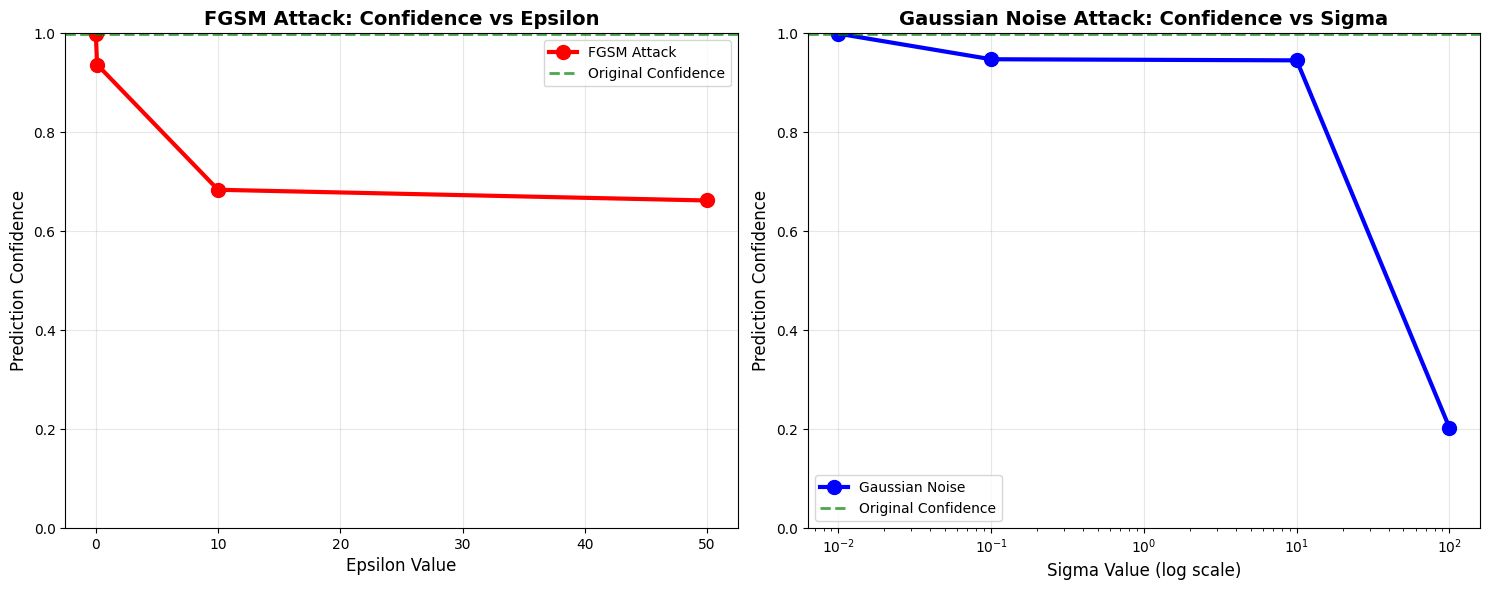

In [ ]:
# Plot confidence comparison
visualizer.plot_confidence_comparison(original_conf, fgsm_results, gaussian_results)

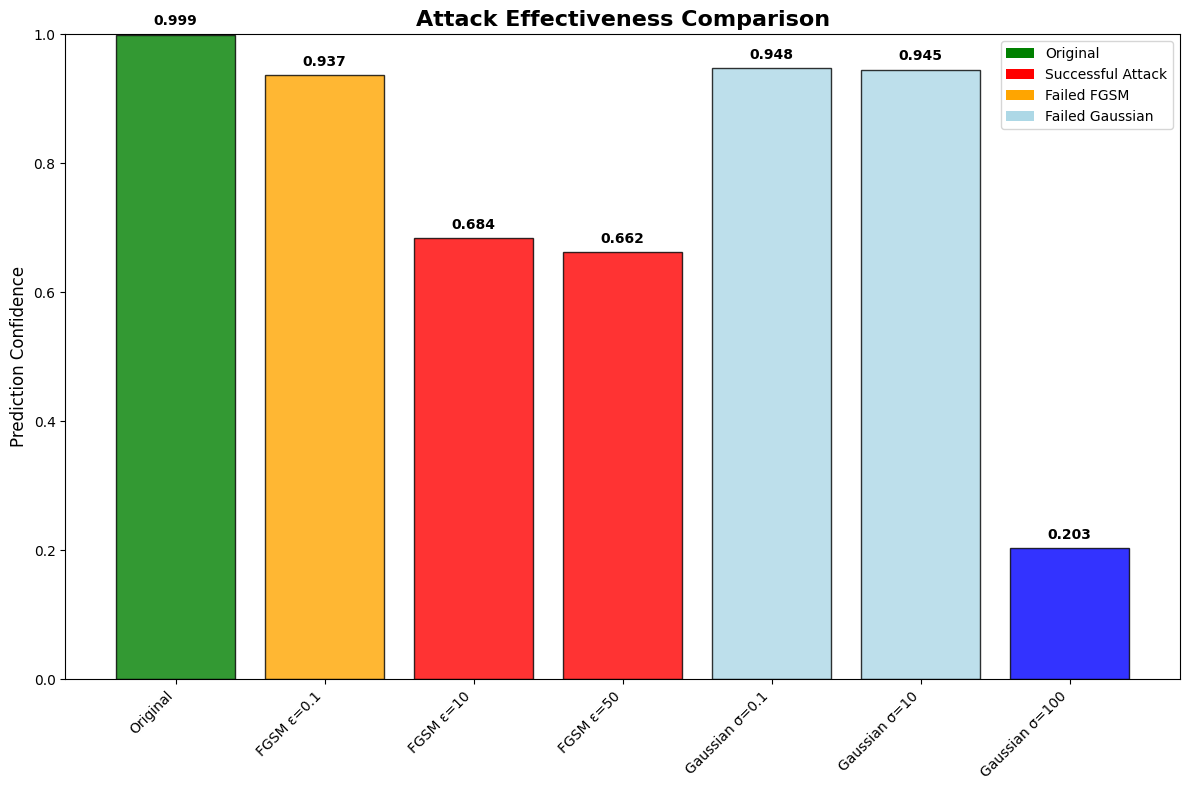

In [ ]:
# Plot attack effectiveness summary
visualizer.plot_attack_effectiveness(original_pred, original_conf, fgsm_results, gaussian_results)